# Assignment 3
**IND 320 -  Data to Decision 2025** \
by Amelie Leonardi

**Use of AI**

I used ChatGPT (GPT-5.0, GPT-4.1), Gemini and GitHub Copilot in VS Code to accelerate routine coding. Espacially AI was used understand how to use the different methods on detecting outlieres for timeseries data. Further it was used to make the plots more readable. I reviewed, adapted, and tested all suggestions; modeling choices and plots are my own. No synthetic data was generated, and no confidential data was shared.


GitHub URL: https://github.com/amelieleo/IND320_2025_amelieleo.git 

Streamlit URL: see in github repository 

**LOG**

This time, it took me a very long time to create the plots. It was particularly difficult for me to apply the various methods to timeseries data. I used ChatGPT and GitHub Copilot in VS Code a lot to help me understand the methods and how to apply them to time series data. Overall, I tried to stick as closely as possible to the examples from the lectures. 

I found it particularly difficult to link DCT and robust statistics. I was unable to calculate and plot the upper and lower limits correctly. For the parameters, I mostly followed the examples from the lecture.

It was easier to apply the method with LocalOutlierFactor. However, some of the results do not seem to make sense. I was unable to conclusively determine whether this was due to an error in my code or whether the method is not particularly suitable for time series. 

For the LOESS decomposition, I attempted to take the seasonality of the data into account when selecting the parameters. In doing so, I attempted to capture daily, weekly and monthly seasonality. 

I also found the spectrogram display rather difficult; I find it very difficult to interpret these for the production data. Therefore, I couldn't check the results for plausibility.

I then integrated all the new components into the Streamlit app. For most parameters, I opted for sliders, as this seems most intuitive to me. To limit the values of the sliders, I simply used a range around the previously set default value.

For the LOESS decomposition, I added a selection option for different period lengths (daily, weekly, monthly). Here, I based my selection on the parameters I had previously used in the Jupyter notebooks.

Some plots take a very long time to compute, and I have tried to inform the user of this. In some cases, the app is also relatively slow. I am currently unable to identify the reason for this. For this submission, I have divided the code into different Python filesin order to increase speed. 

Another task that I have not yet been able to implement is to convert the images to Plotly in order to increase interactivity.


In [1]:
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry
from matplotlib.lines import Line2D
import numpy as np
from scipy.fft import dct, idct
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from datetime import datetime
from zoneinfo import ZoneInfo
from dateutil.relativedelta import relativedelta
import requests
from scipy import stats 
import pymongo

In [2]:
cities = [
    {"Price Area Code": "NO1", "Representative City": "Oslo", "Latitude": 59.911491, "Longitude": 10.757933},
    {"Price Area Code": "NO2", "Representative City": "Kristiansand", "Latitude": 58.1467, "Longitude": 7.9956},
    {"Price Area Code": "NO3", "Representative City": "Trondheim", "Latitude": 63.42, "Longitude": 10.45},
    {"Price Area Code": "NO4", "Representative City": "Tromsø", "Latitude": 69.649208, "Longitude": 18.954343},
    {"Price Area Code": "NO5", "Representative City": "Bergen", "Latitude": 60.392078, "Longitude": 5.327885}
]

# Create the pandas DataFrame
price_areas = pd.DataFrame(cities)

#city as index
price_areas.set_index('Representative City', inplace=True)

# Print the DataFrame
print(price_areas)

                    Price Area Code   Latitude  Longitude
Representative City                                      
Oslo                            NO1  59.911491  10.757933
Kristiansand                    NO2  58.146700   7.995600
Trondheim                       NO3  63.420000  10.450000
Tromsø                          NO4  69.649208  18.954343
Bergen                          NO5  60.392078   5.327885


In [3]:
def load_weather_data(price_area: str, year: int = 2021) -> pd.DataFrame:
   
    cities = [
        {"Price Area Code": "NO1", "Representative City": "Oslo", "Latitude": 59.911491, "Longitude": 10.757933},
        {"Price Area Code": "NO2", "Representative City": "Kristiansand", "Latitude": 58.1467, "Longitude": 7.9956},
        {"Price Area Code": "NO3", "Representative City": "Trondheim", "Latitude": 63.42, "Longitude": 10.45},
        {"Price Area Code": "NO4", "Representative City": "Tromsø", "Latitude": 69.649208, "Longitude": 18.954343},
        {"Price Area Code": "NO5", "Representative City": "Bergen", "Latitude": 60.392078, "Longitude": 5.327885}
    ]

    # Create the pandas DataFrame
    price_areas = pd.DataFrame(cities)

    #city as index
    price_areas.set_index('Price Area Code', inplace=True)

    lat = price_areas.loc[price_area, 'Latitude']
    lon = price_areas.loc[price_area, 'Longitude']

    cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
    retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
    openmeteo = openmeteo_requests.Client(session = retry_session)

    start_date = f"{year}-01-01"
    end_date = f"{year}-12-31"
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": ["precipitation", "temperature_2m", "wind_speed_10m", "wind_direction_10m", "wind_gusts_10m"],
        "models": "era5",
        "timezone": "Europe/Oslo",
    }
    responses = openmeteo.weather_api(url, params=params)

    response = responses[0]

    # Process hourly data. The order of variables needs to be the same as requested.
    hourly = response.Hourly()
    dt_index_utc = pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=int(hourly.Interval())),
        inclusive="left",
    )
    dt_index_oslo = dt_index_utc.tz_convert("Europe/Oslo")  # +01 in winter, +02 in summer

    hourly_data = {
        "date": dt_index_oslo,
        "precipitation": hourly.Variables(0).ValuesAsNumpy(),
        "temperature_2m": hourly.Variables(1).ValuesAsNumpy(),
        "wind_speed_10m": hourly.Variables(2).ValuesAsNumpy(),
        "wind_direction_10m": hourly.Variables(3).ValuesAsNumpy(),
        "wind_gusts_10m": hourly.Variables(4).ValuesAsNumpy(),
    }
    hourly_dataframe = pd.DataFrame(hourly_data)
    
    return hourly_dataframe

In [4]:
bergen = load_weather_data("NO5", year=2021)

In [5]:
bergen

,date,precipitation,temperature_2m,wind_speed_10m,wind_direction_10m,wind_gusts_10m
0,2021-01-01 00:00:00+01:00,0.0,1.068,7.200000,53.130020,12.599999
1,2021-01-01 01:00:00+01:00,0.0,0.818,8.145870,44.999897,12.599999
2,2021-01-01 02:00:00+01:00,0.0,0.668,8.714677,38.290207,12.959999
3,2021-01-01 03:00:00+01:00,0.0,0.868,9.387651,32.471172,13.320000
4,2021-01-01 04:00:00+01:00,0.0,0.468,9.199390,30.579157,13.320000
...,...,...,...,...,...,...
8755,2021-12-31 19:00:00+01:00,0.0,7.518,5.959060,244.983139,13.320000
8756,2021-12-31 20:00:00+01:00,0.3,7.668,5.634891,296.564972,15.840000
8757,2021-12-31 21:00:00+01:00,0.0,6.968,7.895416,335.772278,14.040000
8758,2021-12-31 22:00:00+01:00,0.0,6.268,10.365251,339.676788,19.799999


## Analyzing the Temperature

In [5]:
colors = {
    "temperature": "#C4611A",
    "precipitation": "#3173EE",
    "wind speed": "#AD4DE0",
    "wind gusts": "#3C1053",
    "wind direction": "#075E50",
}

colors_2 = {
    "temperature_2m": "#C4611A",
    "precipitation": "#3173EE",
    "wind_speed_10m": "#AD4DE0",
    "wind_gusts_10m": "#3C1053",
    "wind_direction_10m": "#075E50",
}

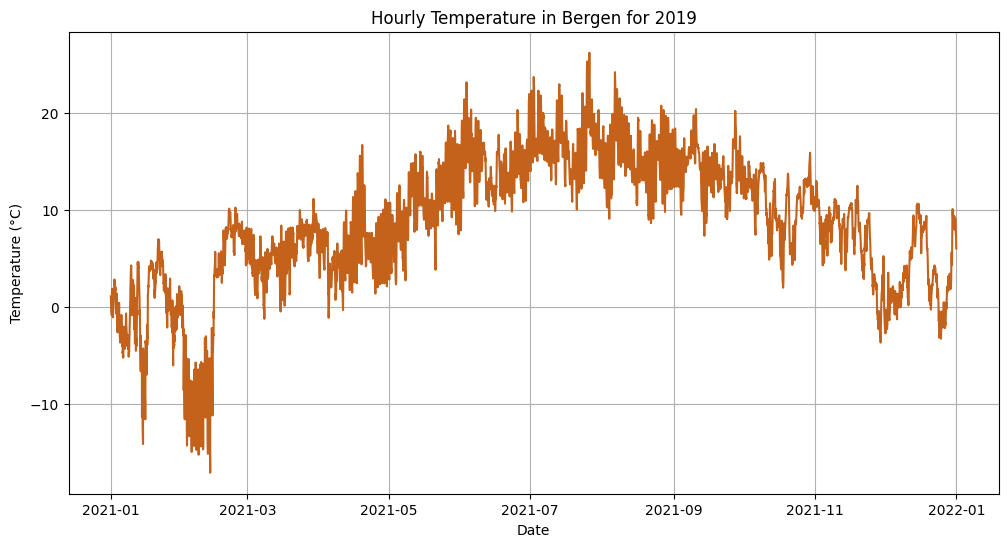

In [6]:
#plot temperature over time
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(bergen['date'], bergen['temperature_2m'], label='Temperature (°C)', color=colors["temperature"])
ax.set_title('Hourly Temperature in Bergen for 2019')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.grid()
plt.show()

In [ ]:
def dct_outliers(df: pd.DataFrame, target_col: str, freq_cutoff: float = 0.02, norm: str = 'ortho', type: int = 1, trim_percent: float = 0.05, n_std: float = 3.0 ) -> plt.Figure:
    series = df[["date", target_col]].copy()
    series.sort_values("date", inplace=True)
    series.set_index("date", inplace=True)
    series[target_col] = (
        series[target_col]
        .interpolate(method="time")
        .bfill()
        .ffill()
    )
    signal = series[target_col].to_numpy()
    t = series.index
    

    # Prepare for DCT
    N = len(signal)
    W = np.arange(0,N)
    fourier_signal_coeffs = dct(signal, type=type, norm=norm)

    satv_coeffs = fourier_signal_coeffs.copy()
    # High-pass filtering: zero out low-frequency components
    cutoff_index = int(N * freq_cutoff)
    satv_coeffs[(W <= cutoff_index)] = 0

    # Inverse DCT to get SATV
    satv = idct(satv_coeffs, type=type, norm=norm)

    # Calculate robust center using trimmed mean
    robust_center = stats.trim_mean(satv, trim_percent)
    mad = stats.median_abs_deviation(satv)
    # Scale MAD to approximate the standard deviation of a normal distribution
    robust_std_estimate = mad * 1.4826 
    
    # Define SPC boundaries
    upper_bound = robust_center + n_std * robust_std_estimate
    lower_bound = robust_center - n_std * robust_std_estimate

    # We plot the boundaries on the main signal's mean for context on the original plot
    trend = signal - satv
    ucl_curve = trend + upper_bound
    lcl_curve = trend + lower_bound
    
    outlier_mask = (satv > upper_bound) | (satv < lower_bound)
    outlier_points_x = outlier_points = series.loc[outlier_mask, target_col]

    line_color = colors_2[target_col]
    limit_color = "#726F6F"
    out_color = '#FF0000'

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(t, signal, color=line_color, label=f"{target_col.capitalize()} Data", linewidth=1.2)
    
    # Plot the UCL and LCL lines

    
    ax.plot(t, ucl_curve , color=limit_color, linestyle="--", linewidth=0.5, label=f"UCL (k={n_std})")
    ax.plot(t, lcl_curve, color=limit_color, linestyle="--", linewidth=0.5, label=f"LCL (k={n_std})")
    
    # Plot outliers using scatter if they exist
    if outlier_mask.any():
        # Plot using the correctly extracted outlier points
        ax.scatter(outlier_points_x.index, outlier_points_x.values, s=14, color=out_color, label="Outliers", zorder=3)

    ax.set_title(f"{target_col.capitalize()} with SPC Limits (robust, DCT high-pass)")
    ax.set_xlabel("Time")
    ax.set_ylabel(f"{target_col.capitalize()}")
    ax.grid(True, alpha=0.3)
    ax.legend()

    return fig


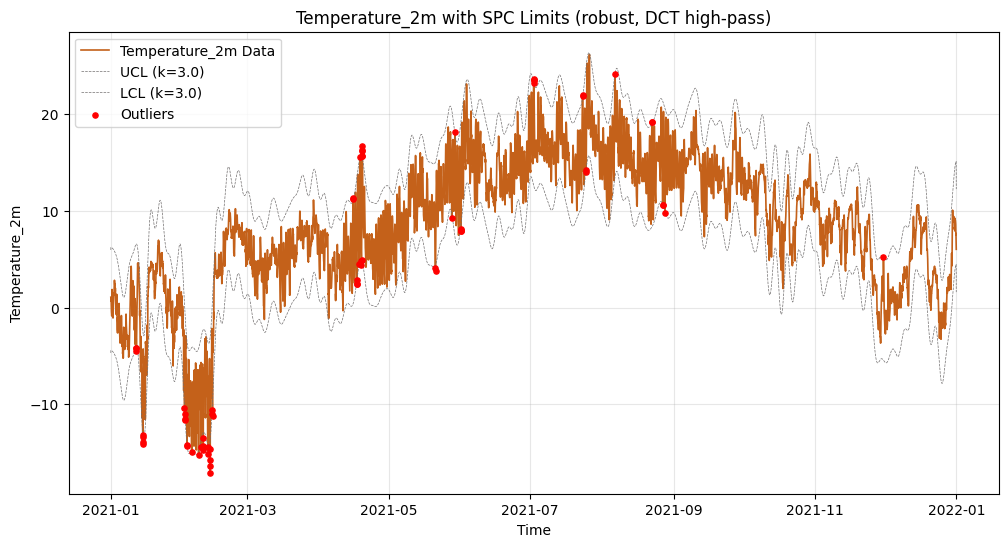

In [16]:
fig = dct_outliers(bergen, target_col="temperature_2m")

## Analyzing precipitation

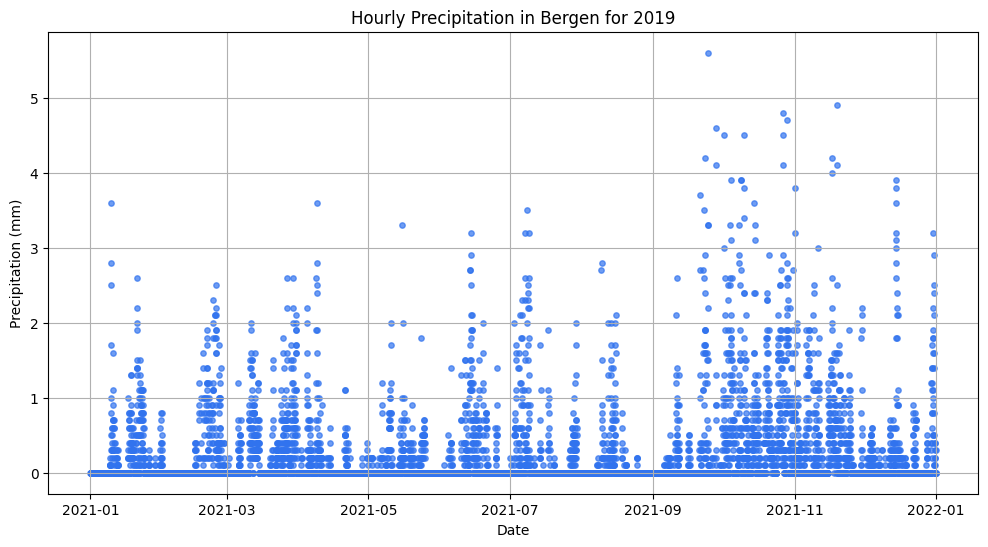

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(bergen['date'], bergen['precipitation'], label='Precipitation (mm)', color=colors["precipitation"], s=15, alpha=0.7)
ax.set_title('Hourly Precipitation in Bergen for 2019')
ax.set_xlabel('Date')
ax.set_ylabel('Precipitation (mm)')
ax.grid()
plt.show()

In [11]:
def apply_lof_time_series(df: pd.DataFrame, target_col: str, n_neighbors: int = 20, contamination: float = 0.01) -> plt.Figure:
    
    # 1. Feature Engineering: Create lagged features
    X = df[[target_col]].sort_index().to_numpy().reshape(-1, 1)
    
    # The indices of the new data correspond to the original df indices after dropping initial NaNs
    original_indices = df.index

    # 2. Fit the LOF model on the multi-dimensional feature set
    # n_neighbors should generally be > window_size + 1
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
    y_pred = lof.fit_predict(X)
    outlier_mask = (y_pred == -1)

    # 3. Prepare data for plotting using the original time indices
    y = df.loc[original_indices, target_col].to_numpy() # Get corresponding original values
    idx_inliers = original_indices[~outlier_mask]
    idx_outliers = original_indices[outlier_mask]
    
    y_inliers = y[~outlier_mask]
    y_outliers = y[outlier_mask]

    # 4. Plot the results
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.scatter(idx_inliers, y_inliers, label='Inlier', color='blue', s=15, alpha=0.6)
    ax.scatter(idx_outliers, y_outliers, label='Outlier', color='red', s=20, alpha=0.8)
    ax.set_title(f'{target_col.capitalize()} Outliers Detected by LOF (n_neighbors={n_neighbors}, contamination={contamination})')
    ax.set_xlabel('Date')
    ax.set_ylabel(f'{target_col.capitalize()}')
    ax.grid()
    ax.legend()

    return fig


C:\Users\ameli\AppData\Local\Temp\ipykernel_3156\3245397661.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  pic.show()


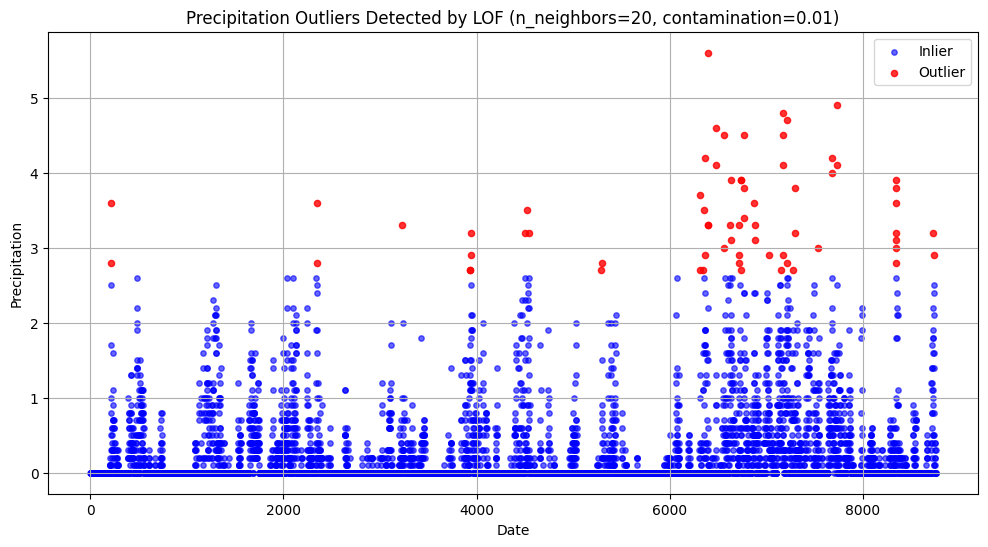

In [12]:
pic = apply_lof_time_series(bergen, target_col="precipitation", n_neighbors=20, contamination=0.01)
pic.show()

## Analyzing the production data

In [13]:
#connecting to MongoDB
from pymongo import MongoClient
from pathlib import Path

USR, PWD = open('../No_sync/MongoDB').read().splitlines()
uri = ("mongodb+srv://{}:{}@cluster0.s1en1xw.mongodb.net/?retryWrites=true&w=majority&appName=Cluster0")

client = MongoClient(uri.format(USR, PWD))
# Send a ping to confirm a successful connection
try:
    client.admin.command('ping')
    print("Pinged your deployment. You successfully connected to MongoDB!")
except Exception as e:
    print(e)

database = client['electricity_production']
collection = database['data_2021']   

Pinged your deployment. You successfully connected to MongoDB!


In [14]:
#read data from MongoDB
data = pd.DataFrame(list(collection.find()))

C:\Users\ameli\AppData\Local\Temp\ipykernel_3156\3993930439.py:6: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  ax.plot(pd.to_datetime(df_filtered["starttime"]), df_filtered["quantitykwh"], color=colors["wind speed"])


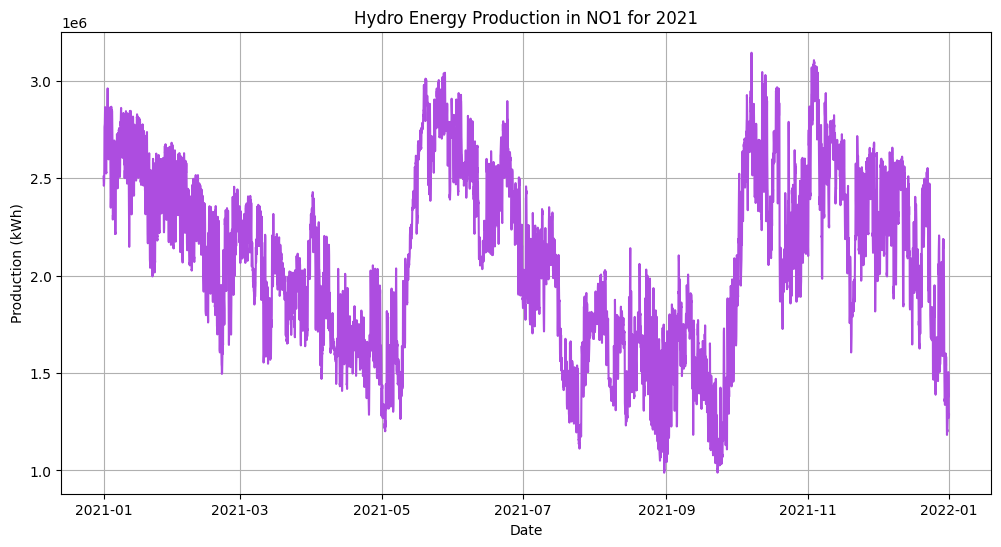

In [15]:
mask = (data["pricearea"] == 'NO1') & (data["productiongroup"] == "hydro")
df_filtered = data.loc[mask].copy()
df_filtered.sort_values("starttime", inplace=True)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(pd.to_datetime(df_filtered["starttime"]), df_filtered["quantitykwh"], color=colors["wind speed"])
ax.set_title('Hydro Energy Production in NO1 for 2021')
ax.set_xlabel('Date')
ax.set_ylabel('Production (kWh)')
ax.grid()
plt.show()


In [16]:
def LOESS_energy_production(
    df: pd.DataFrame,
    price_area: str = "NO1",
    production_group: str = "hydro",
    period_length: int = 24 * 7,
    seasonal_smoothing: int = 25,
    trend_smoothing: int = 24 * 7 * 4 + 1, 
    robust: bool = True,
) -> plt.Figure:
    mask = (df["pricearea"] == price_area) & (df["productiongroup"] == production_group)
    df_filtered = df.loc[mask].copy()
    if df_filtered.empty:
        raise ValueError("No rows for given price_area/production_group")

    # ensure datetime and ordering
    df_filtered["starttime"] = pd.to_datetime(df_filtered["starttime"])
    df_filtered.sort_values("starttime", inplace=True)
    df_filtered.set_index("starttime", inplace=True)

    # STL decomposition and plot
    stl = STL(df_filtered["quantitykwh"].astype(float), period=period_length, robust=robust, seasonal=seasonal_smoothing, trend=trend_smoothing)
    res = stl.fit()
    fig = res.plot()
    fig.suptitle(f"STL decomposition — {production_group} in {price_area}")
    plt.tight_layout()

    #Improve datetime ticks: locator + concise formatter + rotated labels
    import matplotlib.dates as mdates
    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    for ax in fig.axes:
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(formatter)
        plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

    fig.tight_layout()
    plt.subplots_adjust(bottom=0.22)  # give room for rotated labels
    return fig

C:\Users\ameli\AppData\Local\Temp\ipykernel_3156\650796320.py:16: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_filtered["starttime"] = pd.to_datetime(df_filtered["starttime"])
C:\Users\ameli\AppData\Local\Temp\ipykernel_3156\3265725337.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  loes_pic_solar.show()


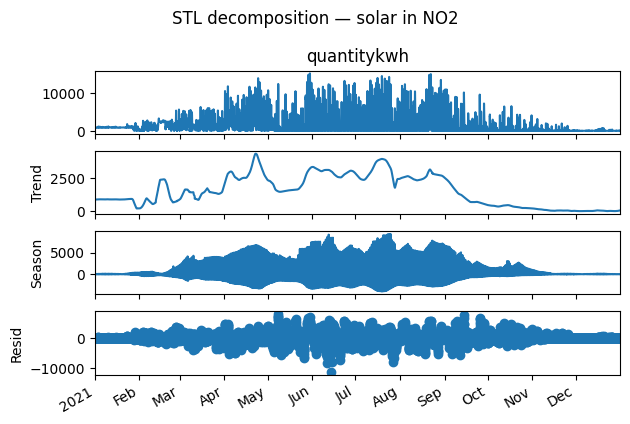

In [17]:
loes_pic_solar = LOESS_energy_production(
    data, price_area="NO2", production_group="solar",
    period_length=24, seasonal_smoothing=13, trend_smoothing=24*3+1, 
    robust=True,
)
loes_pic_solar.show()

C:\Users\ameli\AppData\Local\Temp\ipykernel_3156\650796320.py:16: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_filtered["starttime"] = pd.to_datetime(df_filtered["starttime"])
C:\Users\ameli\AppData\Local\Temp\ipykernel_3156\647691695.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  loes_pic_wind.show()


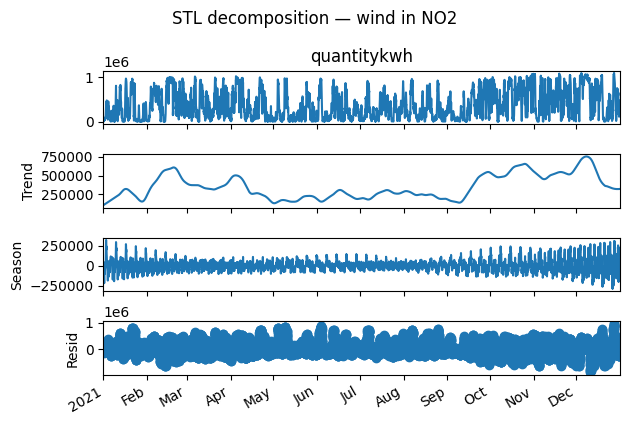

In [18]:
loes_pic_wind = LOESS_energy_production(
    data, price_area="NO2", production_group="wind",
    period_length=24*7, seasonal_smoothing=25, trend_smoothing=24*7*3+1, 
    robust=True,
)
loes_pic_wind.show()

C:\Users\ameli\AppData\Local\Temp\ipykernel_3156\650796320.py:16: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_filtered["starttime"] = pd.to_datetime(df_filtered["starttime"])
C:\Users\ameli\AppData\Local\Temp\ipykernel_3156\3682496435.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  loes_pic_hydro.show()


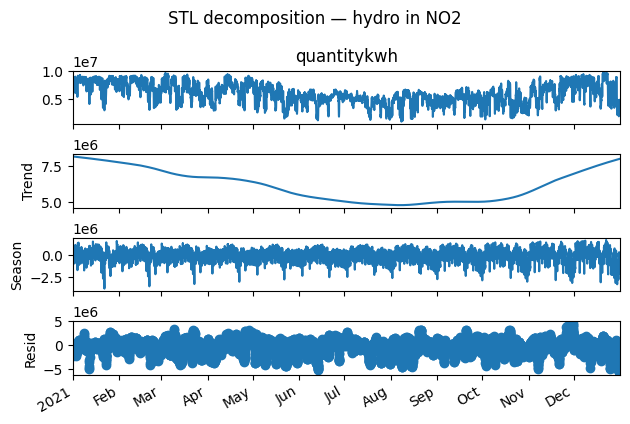

In [19]:
loes_pic_hydro = LOESS_energy_production(
    data, price_area="NO2", production_group="hydro",
    period_length=24*30, seasonal_smoothing=24*7+1, trend_smoothing=3 * 24*30 + 1, 
    robust=True,
)
loes_pic_hydro.show()

In [20]:
def spectrogram_energy_production(
    df: pd.DataFrame, 
    price_area: str = "NO1",
    production_group: str = "hydro",
    NFFT: int = 24*7*4,
    Fs: int = 1,
    noverlap: int = 24*7*4 // 2  
) -> plt.Figure:
    mask = (df["pricearea"] == price_area) & (df["productiongroup"] == production_group)
    df_filtered = df.loc[mask].sort_values("starttime").copy()
    x = df_filtered['quantitykwh'].to_numpy()
    fig, ax = plt.subplots(figsize=(12, 6))
    Pxx, freqs, bins, im = ax.specgram(x, NFFT=NFFT, Fs=Fs, noverlap=noverlap)
    ax.set_xlabel('Time')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Spectrogram of {production_group} production in {price_area}')
    fig.tight_layout()
    plt.subplots_adjust(bottom=0.22)  # give room for rotated labels
    plt.colorbar(im, ax=ax).set_label('Intensity [dB]') 
    return fig, Pxx, freqs, bins

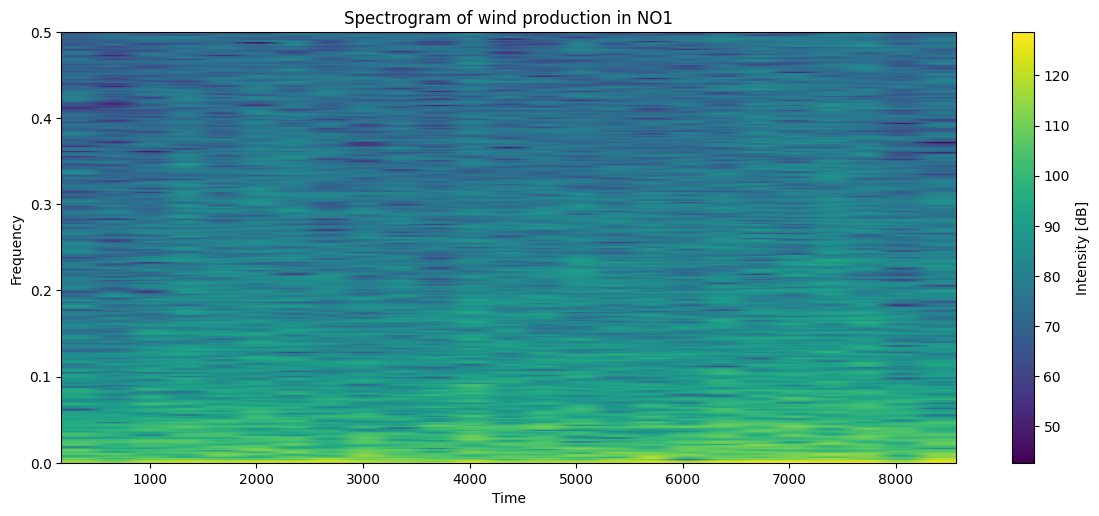

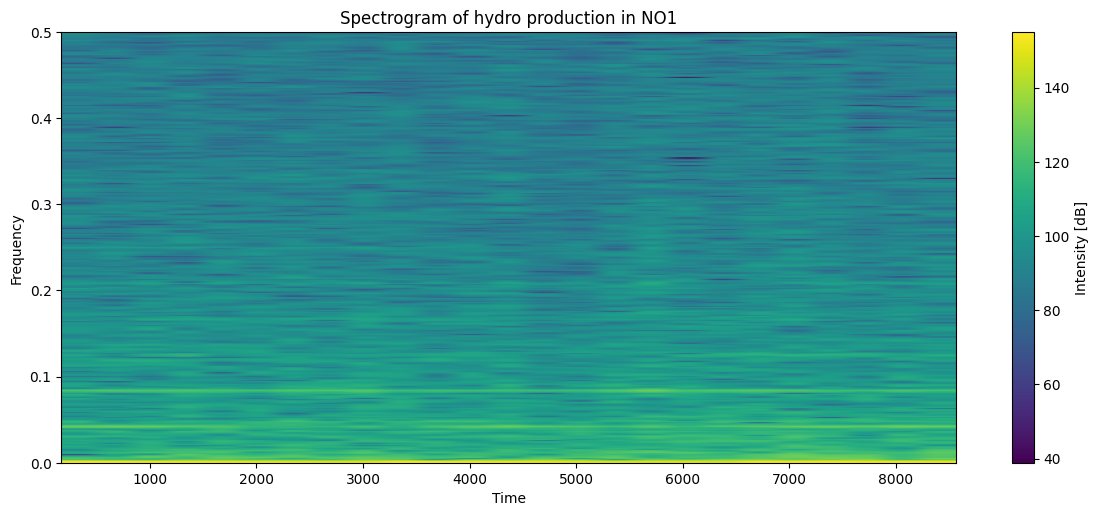

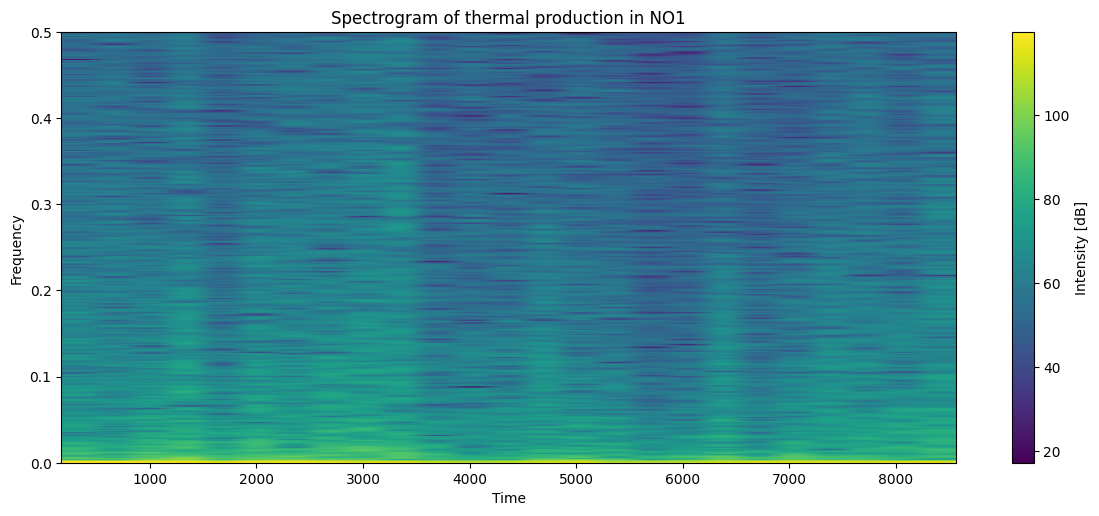

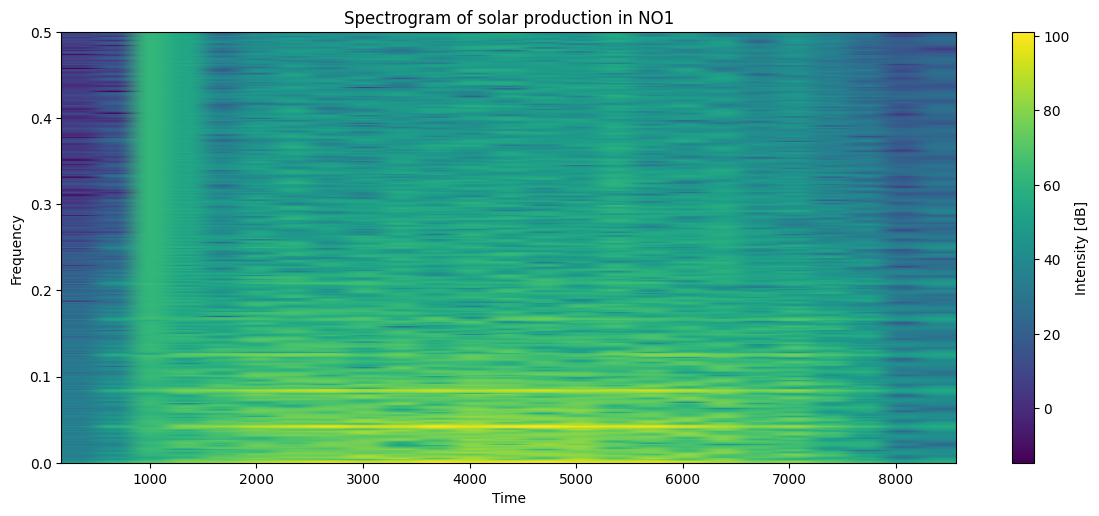

In [21]:
spec_wind_no1 = spectrogram_energy_production(
    data, price_area="NO1", production_group="wind")
plt.show()
spec_hydro_no1 = spectrogram_energy_production(
    data, price_area="NO1", production_group="hydro"
)
plt.show()
spec_thermal_no1 = spectrogram_energy_production(
    data, price_area="NO1", production_group="thermal"
)
plt.show()
spec_solar_no1 = spectrogram_energy_production(
    data, price_area="NO1", production_group="solar"
)
plt.show()